In [3]:
import os
import pandas as pd
import numpy as np

In [4]:
base_dir = os.getcwd()
data_path = os.path.join(base_dir, '..', 'data', 'Fitbit_dataset.csv')

df = pd.read_csv(data_path)

In [5]:
df.head(2)

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5


Skipping Data Exploration as we using the same Dataset

In [6]:
df.drop(columns='Unnamed: 0', inplace=True, errors='ignore')
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

Encoding

In [7]:
df['Gender'] = df['Gender'].str.strip()
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df['Gender'].head())

0    0
1    1
2    0
3    1
4    1
Name: Gender, dtype: int64


In [8]:
df = pd.get_dummies(df, columns=['Workout_Type'], prefix='Type')

In [9]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage',
       'Water_Intake (liters)', 'Workout_Frequency (days/week)',
       'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET',
       'Calories_Burned (kcal)', 'Type_Cardio', 'Type_HIIT', 'Type_Mixed',
       'Type_Strength', 'Type_Yoga'],
      dtype='object')

In [10]:
df.head(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),...,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal),Type_Cardio,Type_HIIT,Type_Mixed,Type_Strength,Type_Yoga
0,56,0,53.8,1.62,163.0,149.0,71.0,1.01,22.1,3.5,...,20.4,9.5,0.847826,8.054348,437.7,False,True,False,False,False
1,46,1,54.9,1.75,170.0,126.0,73.0,0.25,19.9,3.4,...,18.0,3.0,0.546392,1.639175,22.5,False,False,False,False,True
2,32,0,68.5,1.61,190.0,171.0,60.0,0.33,20.4,2.7,...,26.5,9.5,0.853846,8.111538,183.4,False,True,False,False,False
3,25,1,98.8,1.86,189.0,135.0,69.0,0.78,30.3,4.4,...,28.5,3.0,0.550000,1.650000,127.2,False,False,False,False,True
4,38,1,95.5,1.71,176.0,138.0,66.0,0.55,23.7,2.2,...,32.5,7.0,0.654545,4.581818,240.7,True,False,False,False,False


Outliers and Capping

In [11]:
num_cols_for_clustering = [
    'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
    'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 
    'Water_Intake (liters)', 'Workout_Frequency (days/week)', 
    'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET'
]

for col in num_cols_for_clustering:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower_limit, upper_limit)

In [12]:
cols_to_drop = [
    'Workout_Type', 'Calories_Burned (kcal)', 'Unnamed: 0',
    'Type_Cardio', 'Type_HIIT', 'Type_Mixed', 'Type_Strength', 'Type_Yoga'
]

X_unsup = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Features ready for clustering: {X_unsup.columns.tolist()}")

Features ready for clustering: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET']


Feature Scaling : Standard Scaler

In [13]:
from sklearn.preprocessing import StandardScaler
scaler_unsup = StandardScaler()

original_16_features = [
    'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
    'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 
    'Water_Intake (liters)', 'Workout_Frequency (days/week)', 
    'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET'
]

X_unsup_clean = df[original_16_features]
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup)

X_unsup_16_scaled = scaler_unsup.fit_transform(X_unsup_clean)

X_scaled_df = pd.DataFrame(X_unsup_scaled, columns=X_unsup.columns)

print("Data is Scaled and ready for Clustering!")
display(X_scaled_df.head())

Data is Scaled and ready for Clustering!


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET
0,1.455052,-1.010121,-1.090710,-0.618597,-1.424966,0.071400,0.234450,0.624604,0.042913,-0.157772,-0.697148,-0.142302,-0.978007,1.271842,1.458930,1.473327
1,0.622244,0.989981,-1.007489,0.714199,-0.882883,-1.500891,0.515745,-2.012826,-0.325446,-0.318172,-0.697148,-1.087537,-1.613644,-1.709308,-1.547608,-1.546762
2,-0.543688,-1.010121,0.021427,-0.721120,0.665927,1.575330,-1.312677,-1.735202,-0.241728,-1.440970,-0.697148,-0.142302,0.637571,1.271842,1.518975,1.500251
3,-1.126653,0.989981,2.313792,1.841950,0.588486,-0.885647,-0.046846,-0.173566,1.415889,1.285825,-0.697148,-1.087537,1.167268,-1.709308,-1.511619,-1.541666
4,-0.044003,0.989981,2.064128,0.304108,-0.418240,-0.680565,-0.468790,-0.971735,0.310811,-2.242969,-1.303225,-1.087537,2.226664,0.125246,-0.468871,-0.161446


In [14]:
print(f"Number of features in X_unsup: {len(X_unsup.columns)}")
print(f"Columns: {X_unsup.columns.tolist()}")

Number of features in X_unsup: 16
Columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET']


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle
import pandas as pd

original_16_features = [
    'Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 
    'Resting_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 
    'Water_Intake (liters)', 'Workout_Frequency (days/week)', 
    'Experience_Level', 'BMI', 'Base_MET', 'HR_Intensity', 'Effective_MET'
]

X_unsup_clean = df[original_16_features]

scaler_unsup = StandardScaler()
X_unsup_16_scaled = scaler_unsup.fit_transform(X_unsup_clean)



Data Preprocessing Over

PCA

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

Evaluation: We kept 47.22% of the information.

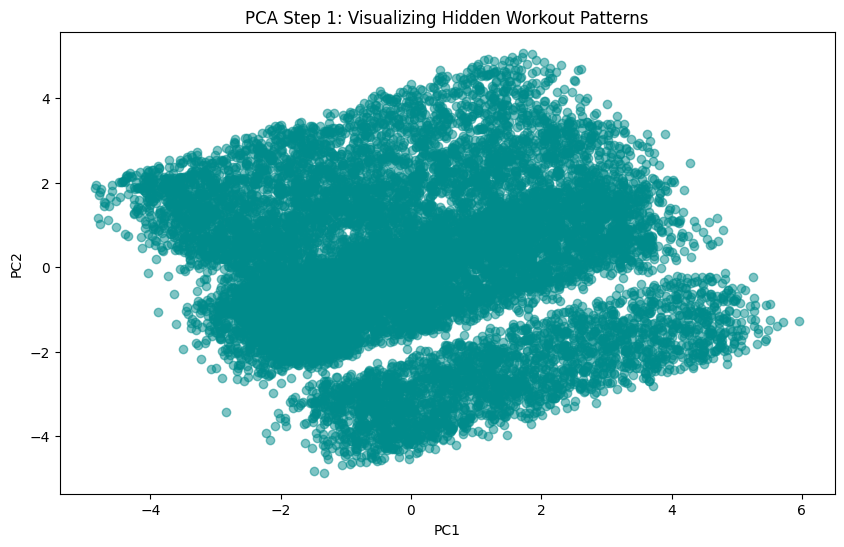

In [17]:
pca = PCA(n_components=2)
pca.fit(X_unsup_16_scaled)

reference_data = pd.DataFrame(X_unsup_16_scaled)
X_pca = pca.transform(X_unsup_16_scaled)
explained_var = pca.explained_variance_ratio_
print(f"Evaluation: We kept {sum(explained_var)*100:.2f}% of the information.")

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color='darkcyan')
plt.title('PCA Step 1: Visualizing Hidden Workout Patterns')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

K Means Clustering

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
k_range = range(2, 11)
wcss = []
silhouette_vals = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_unsup_scaled)
    
    wcss.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_unsup_scaled, labels))
    print(f"For K={k}: Silhouette Score = {silhouette_vals[-1]:.4f}")

For K=2: Silhouette Score = 0.1401
For K=3: Silhouette Score = 0.1701
For K=4: Silhouette Score = 0.1267
For K=5: Silhouette Score = 0.1228
For K=6: Silhouette Score = 0.1283
For K=7: Silhouette Score = 0.1280
For K=8: Silhouette Score = 0.1191
For K=9: Silhouette Score = 0.1228
For K=10: Silhouette Score = 0.1183


In [20]:
for i, value in enumerate(wcss):
    k_val = i + 2
    print(f"Clusters (K={k_val}) -> WCSS (Inertia): {value:.2f}")

reduction = ((wcss[0] - wcss[1]) / wcss[0]) * 100
print(f"\nMoving to K=3 reduced internal cluster tension by {reduction:.2f}%")

Clusters (K=2) -> WCSS (Inertia): 191560.10
Clusters (K=3) -> WCSS (Inertia): 161812.60
Clusters (K=4) -> WCSS (Inertia): 153054.74
Clusters (K=5) -> WCSS (Inertia): 142111.40
Clusters (K=6) -> WCSS (Inertia): 134715.17
Clusters (K=7) -> WCSS (Inertia): 127256.98
Clusters (K=8) -> WCSS (Inertia): 123481.30
Clusters (K=9) -> WCSS (Inertia): 118683.62
Clusters (K=10) -> WCSS (Inertia): 116436.21

Moving to K=3 reduced internal cluster tension by 15.53%


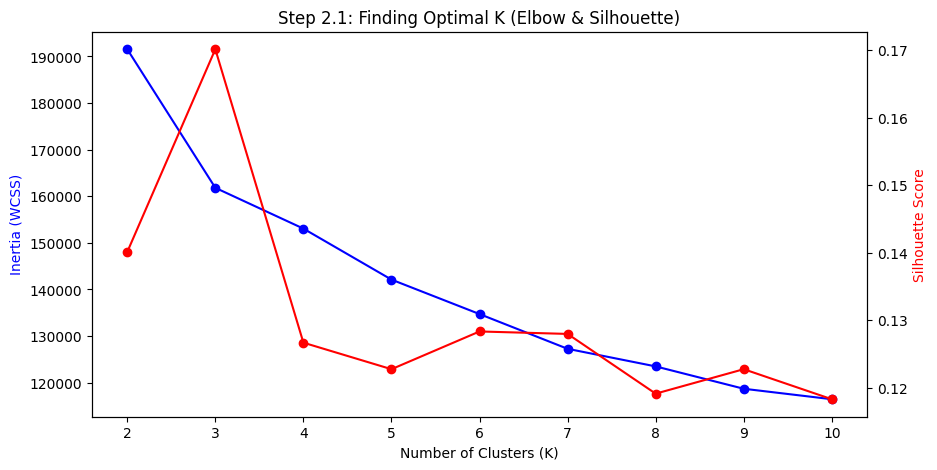

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, wcss, 'bo-', label='WCSS (Elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Step 2.1: Finding Optimal K (Elbow & Silhouette)')
plt.show()

In [22]:
optimal_k = 3 

print(f"Final K-Means Model Trained with K={optimal_k}")
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster_ID'] = kmeans_final.fit_predict(X_unsup_scaled)

Final K-Means Model Trained with K=3


In [23]:
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_unsup_16_scaled)

cluster_summary = df.groupby('KMeans_Cluster')[['Avg_BPM', 'Session_Duration (hours)', 'Fat_Percentage', 'Experience_Level', 'Calories_Burned (kcal)']].mean()

print("\nCluster Personas (Centroids)")
display(cluster_summary)


Cluster Personas (Centroids)


,Avg_BPM,Session_Duration (hours),Fat_Percentage,Experience_Level,Calories_Burned (kcal)
KMeans_Cluster,,,,,
0,153.267543,0.668628,24.995760,0.433151,262.063200
1,150.450308,1.074265,17.063391,2.230431,419.121438
2,130.970557,0.823400,21.988977,1.130700,93.837810



Cluster Size Distribution :
Cluster_ID
0    6769
1    4548
2    2785
Name: count, dtype: int64


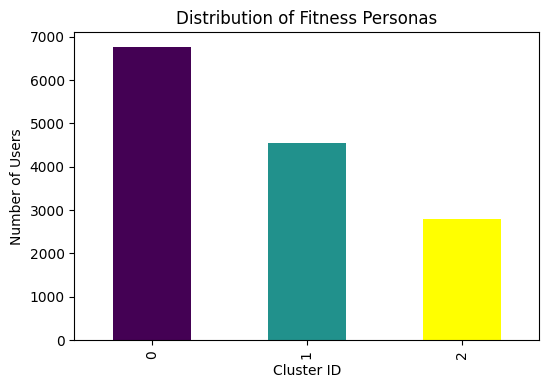

In [24]:
cluster_size = df['Cluster_ID'].value_counts().sort_index()
print("\nCluster Size Distribution :")
print(cluster_size)

plt.figure(figsize=(6, 4))
cluster_size.plot(kind='bar', color=['#440154', '#21918c', 'yellow'])
plt.title('Distribution of Fitness Personas')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Users')
plt.show()

Workout Intensity Clusters

In [25]:
interpretation = df.groupby('Cluster_ID')[['Avg_BPM', 'HR_Intensity', 'Session_Duration (hours)', 'Fat_Percentage', 'Experience_Level']].mean()

print("\nWorkout Intensity Clusters : Cluster Feature Means")
display(interpretation)


Workout Intensity Clusters : Cluster Feature Means


,Avg_BPM,HR_Intensity,Session_Duration (hours),Fat_Percentage,Experience_Level
Cluster_ID,,,,,
0,153.267543,0.738057,0.668628,24.995760,0.433151
1,150.450308,0.739631,1.074265,17.063391,2.230431
2,130.970557,0.550654,0.823400,21.988977,1.130700


In [26]:
exp_comparison = pd.crosstab(df['Cluster_ID'], df['Experience_Level'], normalize='index') * 100

print("\nExperience Level % within each Cluster")
display(exp_comparison.round(2))


Experience Level % within each Cluster


Experience_Level,0,1,2,3
Cluster_ID,,,,
0,58.00,40.69,1.31,0.00
1,0.00,13.74,49.47,36.79
2,35.51,30.34,19.71,14.43


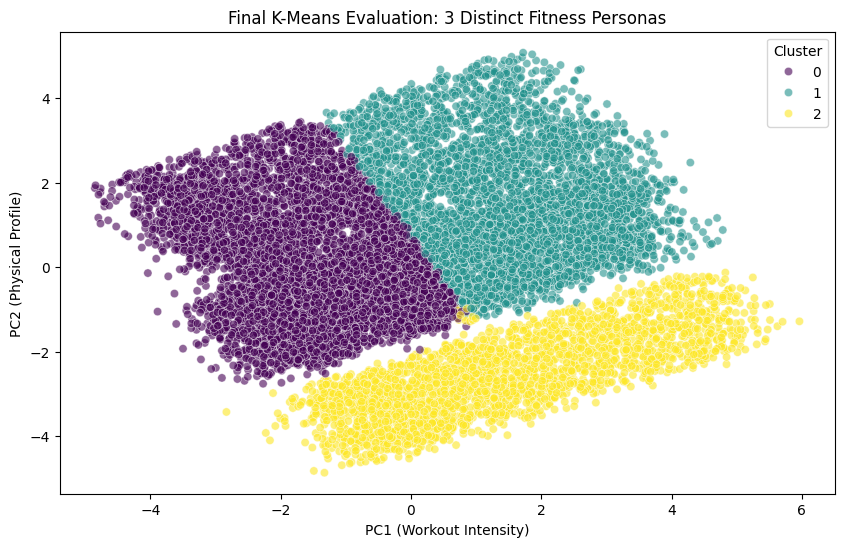

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster_ID'], palette='viridis', alpha=0.6)
plt.title('Final K-Means Evaluation: 3 Distinct Fitness Personas')
plt.xlabel('PC1 (Workout Intensity)')
plt.ylabel('PC2 (Physical Profile)')
plt.legend(title='Cluster')
plt.show()

Hierarchical Clustering

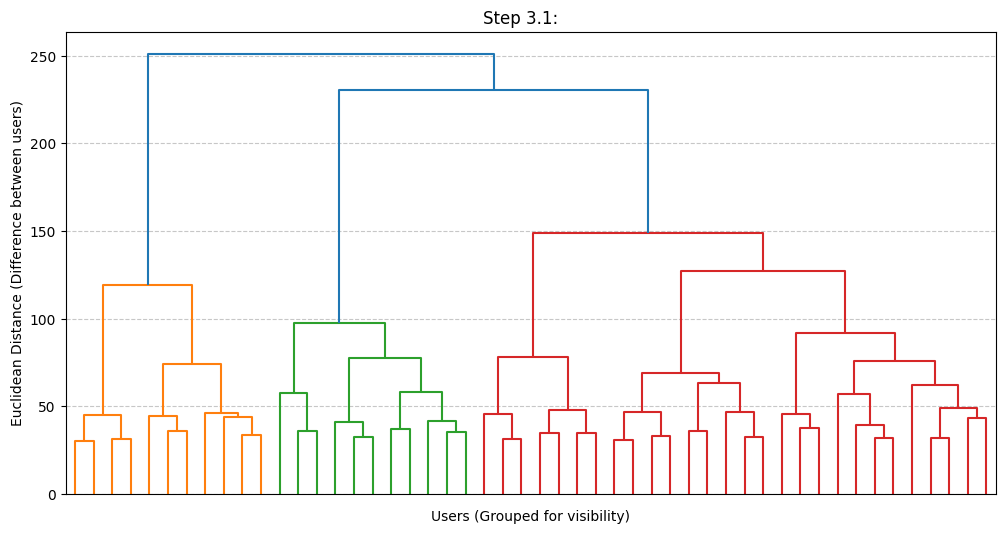

In [28]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(12, 6))
plt.title('Step 3.1:    ')
plt.xlabel('Users (Grouped for visibility)')
plt.ylabel('Euclidean Distance (Difference between users)')

dendrogram = sch.dendrogram(sch.linkage(X_unsup_scaled, method='ward'), truncate_mode='lastp', p=50, show_leaf_counts=False)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering

k_range = range(2, 11)
hc_sil_scores = []

print("Hierarchical Clustering :")

for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = hc.fit_predict(X_unsup_scaled)
    
    score = silhouette_score(X_unsup_scaled, labels)
    hc_sil_scores.append(score)
    print(f"Hierarchical (K={k}) Silhouette Score: {score:.4f}")

Hierarchical Clustering :
Hierarchical (K=2) Silhouette Score: 0.1715
Hierarchical (K=3) Silhouette Score: 0.1545
Hierarchical (K=4) Silhouette Score: 0.1259
Hierarchical (K=5) Silhouette Score: 0.1063
Hierarchical (K=6) Silhouette Score: 0.1081
Hierarchical (K=7) Silhouette Score: 0.1035
Hierarchical (K=8) Silhouette Score: 0.0892
Hierarchical (K=9) Silhouette Score: 0.0863
Hierarchical (K=10) Silhouette Score: 0.0806


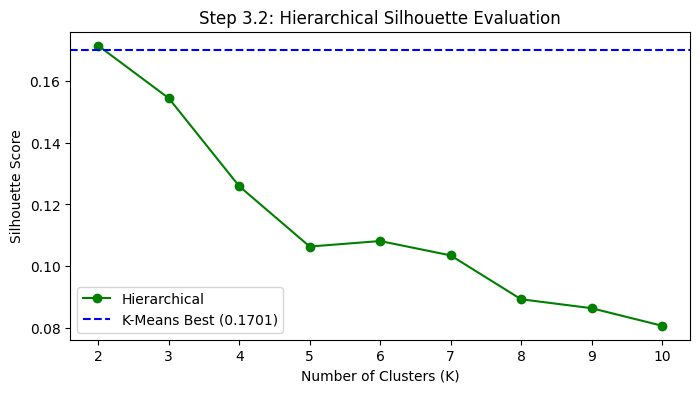

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, hc_sil_scores, 'go-', label='Hierarchical')
plt.axhline(y=0.1701, color='b', linestyle='--', label='K-Means Best (0.1701)')
plt.title('Step 3.2: Hierarchical Silhouette Evaluation')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.show()

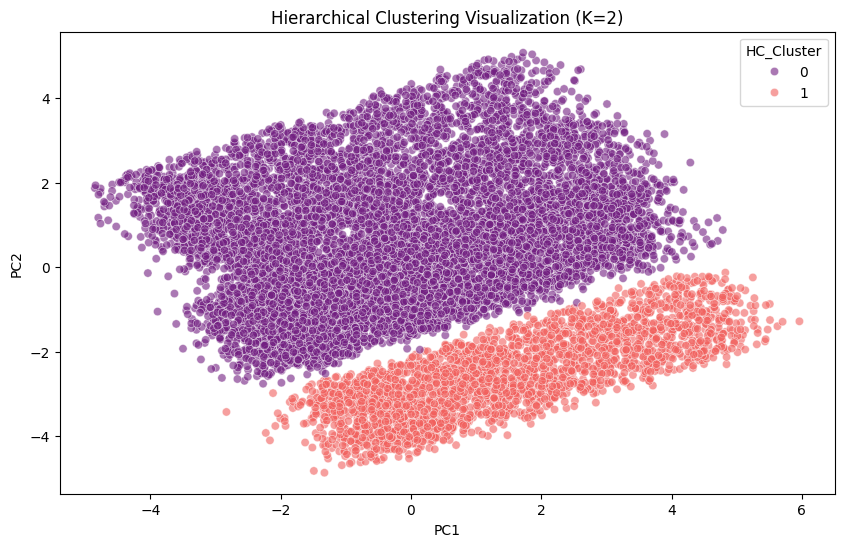

In [31]:
hc_final = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
df['HC_Cluster'] = hc_final.fit_predict(X_unsup_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['HC_Cluster'], palette='magma', alpha=0.6)
plt.title('Hierarchical Clustering Visualization (K=2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

DBSCAN (Density-Based Spatial Clustering)

In [32]:
from sklearn.neighbors import NearestNeighbors

print("Nearest Neighbors for DBSCAN")

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_unsup_scaled)
distances, indices = neighbors_fit.kneighbors(X_unsup_scaled)

distances = np.sort(distances[:, 4], axis=0)

Nearest Neighbors for DBSCAN


Find Optimal Epsilon Value

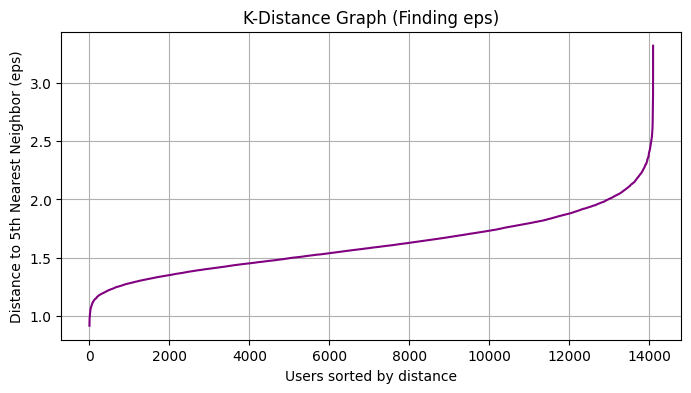

In [48]:
plt.figure(figsize=(8, 4))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph (Finding eps)')
plt.xlabel('Users sorted by distance')
plt.ylabel('Distance to 5th Nearest Neighbor (eps)')
plt.grid(True)
plt.show()

In [36]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

optimal_eps = 2.2

print(f"Executed DBSCAN with eps={optimal_eps}")

dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
db_labels = dbscan.fit_predict(X_unsup_scaled)


Executed DBSCAN with eps=2.2


In [37]:
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
total_users = len(db_labels)

print("\nDBSCAN Results :")
print(f"Estimated Clusters Found: {n_clusters}")
print(f"Outliers (Noise) Found: {n_noise} out of {total_users} users ({(n_noise/total_users)*100:.2f}%)")

if n_clusters > 1:
    mask = db_labels != -1
    if len(set(db_labels[mask])) > 1:
        db_score = silhouette_score(X_unsup_scaled[mask], db_labels[mask])
        print(f"DBSCAN Silhouette Score (Valid points only): {db_score:.4f}")
else:
    print("Not enough clusters found to calculate Silhouette Score.")


DBSCAN Results :
Estimated Clusters Found: 2
Outliers (Noise) Found: 52 out of 14102 users (0.37%)
DBSCAN Silhouette Score (Valid points only): 0.1718


In [38]:
df['DBSCAN_Cluster'] = db_labels

dbscan_interpretation = df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Avg_BPM', 'HR_Intensity', 'Session_Duration (hours)', 'Fat_Percentage']].mean()

print("DBSCAN Cluster Intensity Pattern :")
display(dbscan_interpretation.round(2))

DBSCAN Cluster Intensity Pattern :


,Avg_BPM,HR_Intensity,Session_Duration (hours),Fat_Percentage
DBSCAN_Cluster,,,,
0,152.12,0.74,0.83,21.82
1,130.98,0.55,0.82,22.00


In [39]:
exp_comparison = pd.crosstab(df['DBSCAN_Cluster'], df['Experience_Level'], normalize='index') * 100

print("Experience Level Distribution Percentage %")
display(exp_comparison.round(2))

Experience Level Distribution Percentage %


Experience_Level,0,1,2,3
DBSCAN_Cluster,,,,
-1,13.46,19.23,26.92,40.38
0,34.72,29.98,20.64,14.67
1,35.81,30.05,19.72,14.43


In [40]:
outliers = df[df['DBSCAN_Cluster'] == -1]
print(f"DBSCAN Evaluation: Found {len(outliers)} outliers.")
print("Average stats of these outliers:")
display(outliers[['Avg_BPM', 'Session_Duration (hours)', 'Fat_Percentage']].mean())

DBSCAN Evaluation: Found 52 outliers.
Average stats of these outliers:


Avg_BPM                     143.884615
Session_Duration (hours)      1.055288
Fat_Percentage               18.232692
dtype: float64

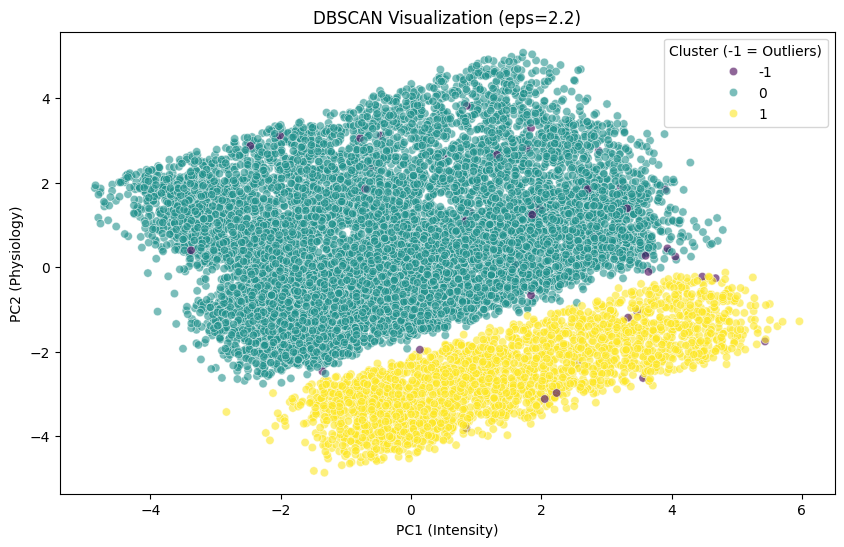

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['DBSCAN_Cluster'], palette='viridis', alpha=0.6)

plt.title(f'DBSCAN Visualization (eps={optimal_eps})')
plt.xlabel('PC1 (Intensity)')
plt.ylabel('PC2 (Physiology)')
plt.legend(title='Cluster (-1 = Outliers)')
plt.show()

Saving the Tuned and Untuned Models as Pickle file

In [ ]:
import pickle

In [ ]:
pickle.dump(scaler_unsup, open('../pickles/scaler_unsupervised.pkl', 'wb'))
pickle.dump(pca, open('../pickles/pca_transformer.pkl', 'wb'))
pickle.dump(reference_data, open('../pickles/unsup_reference.pkl', 'wb'))

In [ ]:
pickle.dump(kmeans_final, open('../pickles/kmeans_final.pkl', 'wb'))
pickle.dump(hc_final, open('../pickles/hc_final.pkl', 'wb'))
pickle.dump(dbscan, open('../pickles/dbscan_final.pkl', 'wb'))